# 03b — Inspección de features diarias y ventanas T=65

Notebook **explicativo / de inspección** sobre los artefactos (`features-0.1.0`).

**Solo lectura.** No recalcula features, no reconstruye ventanas desde OHLCV como pipeline oficial,
no escribe en `data/features/`, no hace splits ni modelos.

La fuente de verdad sigue siendo lo ya generado:
- `data/features/daily_features.parquet`
- `data/features/windows_65.parquet`
- `data/features/features_manifest.json`
- `data/features/README.md`

### Cómo ejecutarlo

Desde la raíz del repo:

```bash
uv pip install --python .venv/bin/python -r requirements.txt matplotlib ipykernel
jupyter notebook notebooks/03b_inspect_features_windows.ipynb
```

Usar el kernel del `.venv` del proyecto. Detalle: `notebooks/README_03b.md`.


## Controles

Parámetros útiles al inicio:

| Control | Default | Uso |
|---|---|---|
| `TICKER` | `"NVDA"` | Serie e histograma del panel diario |
| `TICKER_B` | `"AMD"` | Segunda ventana de ejemplo (comparar escala) |
| `SAVE_FIGS` | `False` | Si `True`, exporta 1–3 figuras a `notebooks/figures/` |


In [2]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Controles ---
TICKER = "NVDA"
TICKER_B = "AMD"   # segunda ventana de ejemplo
SAVE_FIGS = False

# Resolver raíz del repo (cwd = raíz o notebooks/)
cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "data" / "features").is_dir() else cwd.parent
FEATURES_DIR = ROOT / "data" / "features"
FIG_DIR = ROOT / "notebooks" / "figures"

assert FEATURES_DIR.is_dir(), f"No se encuentra data/features en {ROOT}"
print(f"ROOT = {ROOT}")
print(f"TICKER = {TICKER} | TICKER_B = {TICKER_B} | SAVE_FIGS = {SAVE_FIGS}")


ROOT = /home/cristian/Documents/miax/modulo5/2026_Modelos_generativos/taller/taller_cristian
TICKER = NVDA | TICKER_B = AMD | SAVE_FIGS = False


## 1. Contexto del paso 3

Se transformó el panel OHLCV limpio en un panel de **3 features diarias** y luego en
**ventanas deslizantes de 65 días** (stride 1), listas para modelos generativos.

```
data/clean/ohlcv_clean.parquet
        │
        │  por ticker, orden temporal
        │  DROP Volume==0 (antes de features)
        │  3 fórmulas log + drop 1ª fila (sin log_return)
        ▼
data/features/daily_features.parquet
  columnas: date, ticker, log_return, log_high_low_range, log_volume
        │
        │  ventanas T=65, stride=1
        │  filas consecutivas del panel (NO calendario rellenado)
        │  features_flat = 195 floats → reshape(65, 3)
        ▼
data/features/windows_65.parquet
  columnas: ticker, window_start_date, window_end_date, features_flat
```

Documentación canónica: `data/features/README.md` y `features_manifest.json`.


## 2. Verificación SHA + carga del manifest

Si algún SHA no coincide con el esperado del entregable anterior → **PARA** (artefactos no canónicos).


In [3]:
EXPECTED_SHA = {
    "daily_features.parquet": "86e07598ed9e45c6e4b1362b12ad73967f852fcdb13570dc7746496093d10118",
    "windows_65.parquet": "58bf4c4788cc4ae4feed14c2173419dea876a322c9e6f66d510c9dfb6c00bccf",
}

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

sha_rows = []
for name, expected in EXPECTED_SHA.items():
    path = FEATURES_DIR / name
    actual = sha256_file(path)
    ok = actual == expected
    sha_rows.append(
        {
            "artifact": name,
            "path": str(path.relative_to(ROOT)),
            "expected": expected,
            "actual": actual,
            "ok": ok,
        }
    )

sha_df = pd.DataFrame(sha_rows)
display(sha_df)

if not sha_df["ok"].all():
    raise RuntimeError(
        "SHA256 NO coincide con features-0.1.0 canónico. "
        "PARAR: no inspeccionar artefactos no verificados."
    )

print("SHA256 daily_features + windows_65: OK")


,artifact,path,expected,actual,ok
0,daily_features.parquet,data/features/daily_features.parquet,86e07598ed9e45c6e4b1362b12ad73967f852fcdb13570...,86e07598ed9e45c6e4b1362b12ad73967f852fcdb13570...,True
1,windows_65.parquet,data/features/windows_65.parquet,58bf4c4788cc4ae4feed14c2173419dea876a322c9e6f6...,58bf4c4788cc4ae4feed14c2173419dea876a322c9e6f6...,True


SHA256 daily_features + windows_65: OK


In [4]:
manifest_path = FEATURES_DIR / "features_manifest.json"
with manifest_path.open() as f:
    manifest = json.load(f)

print(f"data_version : {manifest['data_version']}")
print(f"built_at_utc : {manifest['built_at_utc']}")
print(f"input_path   : {manifest['input_path']}")
print()
print("--- Fórmulas ---")
for k, v in manifest["formulas"].items():
    print(f"  {k}: {v}")
print()
print("--- Políticas clave ---")
for key in ("volume_eq_0", "high_eq_low", "gaps_vs_union_calendar", "winsorize", "standardize_or_nvda_calibration"):
    print(f"  {key}: {manifest['policies'][key]}")
print()
print(f"n_features_rows = {manifest['n_features_rows']}")
print(f"n_windows       = {manifest['n_windows']}")
print(f"window_params   = {manifest['window_params']}")


data_version : features-0.1.0
built_at_utc : 2026-08-27T12:12:50.430811+00:00
input_path   : data/clean/ohlcv_clean.parquet

--- Fórmulas ---
  log_return: ln(Close_t / Close_{t-1})
  log_high_low_range: ln(High_t / Low_t); 0.0 if High == Low
  log_volume: ln(Volume_t); rows with Volume == 0 are dropped (no ln(1))

--- Políticas clave ---
  volume_eq_0: DROP row before feature computation (no ln(1))
  high_eq_low: log_high_low_range = 0.0
  gaps_vs_union_calendar: no ffill; windows over consecutive rows of the features panel (not calendar-filled days)
  winsorize: NO
  standardize_or_nvda_calibration: NO (out of scope for this chat)

n_features_rows = 38701
n_windows       = 37997
window_params   = {'T': 65, 'stride': 1, 'channel_order': ['log_return', 'log_high_low_range', 'log_volume'], 'tensor_shape': [65, 3], 'features_flat_length': 195, 'features_flat_layout': 'row-major: for t in 0..T-1, channels in channel_order; reshape(65, 3)'}


## 3. Panel diario de features

Columnas (schema canónico):

| Columna | Significado |
|---|---|
| `date` | Día de trading (fila del panel de features) |
| `ticker` | Símbolo |
| `log_return` | $\ln(Close_t / Close_{t-1})$ — retorno logarítmico diario |
| `log_high_low_range` | $\ln(High_t / Low_t)$; si `High == Low` → `0.0` — rango intradía en log |
| `log_volume` | $\ln(Volume_t)$ — filas con `Volume == 0` ya fueron dropeadas (no `ln(1)`) |

Notas de interpretación (breve):

- Las tres features están en **escala log**; son adimensionales o log-unidades, no precios.
- `log_volume` suele tener **media/escala muy distinta entre tickers** (heterocedasticidad documentada; sin winsorize ni estandarizar en esta versión).
- Huecos: no hay ffill; el panel es la secuencia de filas válidas por ticker.


In [5]:
daily = pd.read_parquet(FEATURES_DIR / "daily_features.parquet")

print("shape:", daily.shape)
print()
print("dtypes:")
print(daily.dtypes)
print()
print("--- head ---")
display(daily.head())
print("--- tail ---")
display(daily.tail())


shape: (38701, 5)

dtypes:
date                  datetime64[ms]
ticker                           str
log_return                   float64
log_high_low_range           float64
log_volume                   float64
dtype: object

--- head ---


,date,ticker,log_return,log_high_low_range,log_volume
0,2012-01-04,ADI,-0.001389,0.011990,14.171785
1,2012-01-05,ADI,0.004437,0.013621,14.568953
2,2012-01-06,ADI,-0.006663,0.012222,15.077658
3,2012-01-09,ADI,0.019311,0.021488,14.768673
4,2012-01-10,ADI,0.004362,0.010876,14.485133


--- tail ---


,date,ticker,log_return,log_high_low_range,log_volume
38696,2025-12-24,TXN,0.000282,0.006877,14.051768
38697,2025-12-26,TXN,-0.001412,0.011777,14.975876
38698,2025-12-29,TXN,-0.006751,0.014458,15.241795
38699,2025-12-30,TXN,-0.001538,0.006937,15.177666
38700,2025-12-31,TXN,-0.011063,0.015674,15.047167


In [6]:
counts_daily = daily["ticker"].value_counts().sort_index().rename("n_rows")
manifest_daily = pd.Series(manifest["n_features_rows_by_ticker"]).sort_index().rename("manifest")
cmp_daily = pd.concat([counts_daily, manifest_daily], axis=1)
cmp_daily["match"] = cmp_daily["n_rows"] == cmp_daily["manifest"]
display(cmp_daily)
print(f"total filas = {len(daily)} | manifest = {manifest['n_features_rows']} | match = {len(daily) == manifest['n_features_rows']}")
print(f"rango fechas features: {daily['date'].min().date()} → {daily['date'].max().date()}")
assert cmp_daily["match"].all() and len(daily) == manifest["n_features_rows"]
print("Conteos panel diario alinean con manifest: OK")


,n_rows,manifest,match
ADI,3519,3519,True
AMD,3518,3518,True
AVGO,3519,3519,True
INTC,3516,3516,True
MCHP,3517,3517,True
MRVL,3518,3518,True
MU,3519,3519,True
NVDA,3519,3519,True
NXPI,3519,3519,True
QCOM,3519,3519,True


total filas = 38701 | manifest = 38701 | match = True
rango fechas features: 2012-01-04 → 2025-12-31
Conteos panel diario alinean con manifest: OK


### 3.1 Serie de `log_return` (ticker parametrizable)

Un plot simple para ver la dinámica temporal del retorno log del ticker elegido (`TICKER`).


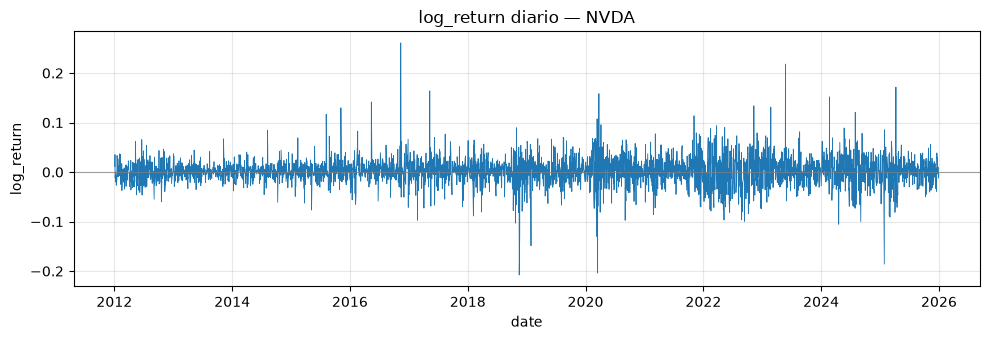

In [7]:
sub = daily.loc[daily["ticker"] == TICKER].sort_values("date")
assert len(sub) > 0, f"TICKER={TICKER!r} no está en el panel"

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(sub["date"], sub["log_return"], lw=0.6, color="C0")
ax.axhline(0.0, color="gray", lw=0.8, alpha=0.7)
ax.set_title(f"log_return diario — {TICKER}")
ax.set_xlabel("date")
ax.set_ylabel("log_return")
ax.grid(True, alpha=0.3)
fig.tight_layout()

if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    out = FIG_DIR / f"03b_log_return_{TICKER}.png"
    fig.savefig(out, dpi=120)
    print(f"guardado: {out.relative_to(ROOT)}")

plt.show()


### 3.2 Densidades / histograma de las 3 features

Comparación visual de las tres features en el mismo ticker (escalas distintas → ejes independientes).


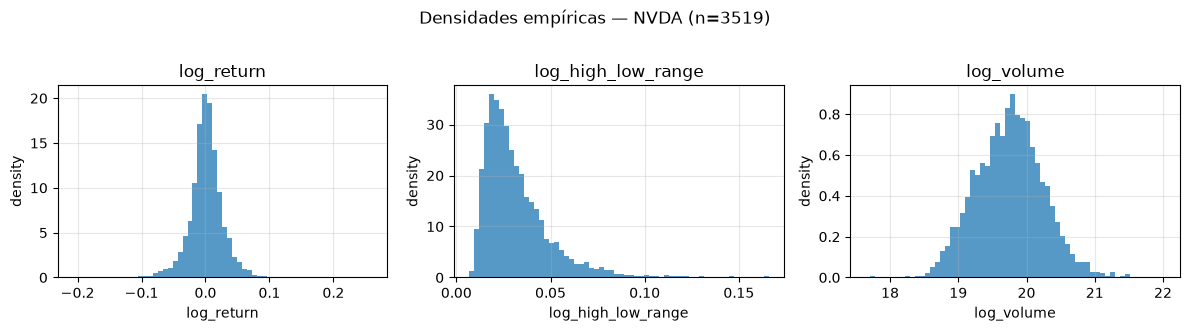

In [8]:
feat_cols = ["log_return", "log_high_low_range", "log_volume"]
sub = daily.loc[daily["ticker"] == TICKER, feat_cols]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col in zip(axes, feat_cols):
    ax.hist(sub[col].to_numpy(), bins=60, density=True, color="C0", alpha=0.75, edgecolor="none")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.grid(True, alpha=0.3)
fig.suptitle(f"Densidades empíricas — {TICKER} (n={len(sub)})", y=1.02)
fig.tight_layout()

if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    out = FIG_DIR / f"03b_feature_densities_{TICKER}.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    print(f"guardado: {out.relative_to(ROOT)}")

plt.show()


## 4. Ventanas de 65 días

Cada fila de `windows_65.parquet` es **una ventana de un solo ticker**:

| Campo | Rol |
|---|---|
| `ticker` | Símbolo de la ventana |
| `window_start_date` | Fecha de la **primera** fila de features de la ventana |
| `window_end_date` | Fecha de la **última** fila (día 65) |
| `features_flat` | Lista de **195** floats (= 65 × 3) en orden row-major |

### Cómo se guarda el tensor

Orden de canales (fijo, del manifest):

```
channel_order = ["log_return", "log_high_low_range", "log_volume"]
```

Layout de `features_flat`:

```
for t in 0..64:
    flat[3*t + 0] = log_return[t]
    flat[3*t + 1] = log_high_low_range[t]
    flat[3*t + 2] = log_volume[t]
```

Reconstruir:

```python
X = np.asarray(row["features_flat"], dtype=np.float64).reshape(65, 3)
# X.shape == (65, 3)
# X[:, 0] → log_return, X[:, 1] → log_high_low_range, X[:, 2] → log_volume
```

Las 65 filas son **filas consecutivas del panel de features** (no días de calendario rellenados).


In [9]:
windows = pd.read_parquet(FEATURES_DIR / "windows_65.parquet")

print("shape:", windows.shape)
print()
print("dtypes:")
print(windows.dtypes)
print()
print("--- head ---")
display(windows.head(3))

# Forma de una fila
row0 = windows.iloc[0]
flat0 = np.asarray(row0["features_flat"], dtype=np.float64)
X0 = flat0.reshape(65, 3)
print()
print(f"features_flat length = {flat0.shape[0]} (esperado 195)")
print(f"reshape → {X0.shape} (esperado (65, 3))")
print(f"ejemplo metadatos: ticker={row0['ticker']} | start={row0['window_start_date'].date()} | end={row0['window_end_date'].date()}")
assert flat0.shape[0] == 195 and X0.shape == (65, 3)


shape: (37997, 4)

dtypes:
ticker                          str
window_start_date    datetime64[ms]
window_end_date      datetime64[ms]
features_flat                object
dtype: object

--- head ---


,ticker,window_start_date,window_end_date,features_flat
0,ADI,2012-01-04,2012-04-05,"[-0.0013888800981320109, 0.011989556282318023,..."
1,ADI,2012-01-05,2012-04-09,"[0.004437410724562126, 0.013620826934154716, 1..."
2,ADI,2012-01-06,2012-04-10,"[-0.006663010028031311, 0.012222442194067425, ..."



features_flat length = 195 (esperado 195)
reshape → (65, 3) (esperado (65, 3))
ejemplo metadatos: ticker=ADI | start=2012-01-04 | end=2012-04-05


In [10]:
counts_win = windows["ticker"].value_counts().sort_index().rename("n_windows")
manifest_win = pd.Series(manifest["n_windows_by_ticker"]).sort_index().rename("manifest")
cmp_win = pd.concat([counts_win, manifest_win], axis=1)
cmp_win["match"] = cmp_win["n_windows"] == cmp_win["manifest"]
display(cmp_win)
print(f"total ventanas = {len(windows)} | manifest = {manifest['n_windows']} | match = {len(windows) == manifest['n_windows']}")

# Relación esperada: n_windows ≈ n_features_rows - 64 por ticker (T=65, stride=1)
rel = cmp_daily[["n_rows"]].join(cmp_win[["n_windows"]])
rel["n_rows - 64"] = rel["n_rows"] - 64
rel["ok"] = rel["n_windows"] == rel["n_rows - 64"]
display(rel)
assert cmp_win["match"].all() and len(windows) == manifest["n_windows"] and rel["ok"].all()
print("Conteos de ventanas alinean con manifest y con (n_features - 64): OK")


,n_windows,manifest,match
ADI,3455,3455,True
AMD,3454,3454,True
AVGO,3455,3455,True
INTC,3452,3452,True
MCHP,3453,3453,True
MRVL,3454,3454,True
MU,3455,3455,True
NVDA,3455,3455,True
NXPI,3455,3455,True
QCOM,3455,3455,True


total ventanas = 37997 | manifest = 37997 | match = True


,n_rows,n_windows,n_rows - 64,ok
ADI,3519,3455,3455,True
AMD,3518,3454,3454,True
AVGO,3519,3455,3455,True
INTC,3516,3452,3452,True
MCHP,3517,3453,3453,True
MRVL,3518,3454,3454,True
MU,3519,3455,3455,True
NVDA,3519,3455,3455,True
NXPI,3519,3455,3455,True
QCOM,3519,3455,3455,True


Conteos de ventanas alinean con manifest y con (n_features - 64): OK


### 4.1 Visualizar una ventana ejemplo (3 canales)

Tomamos la **primera** ventana del `TICKER` elegido y dibujamos los 3 canales a lo largo de los 65 pasos.


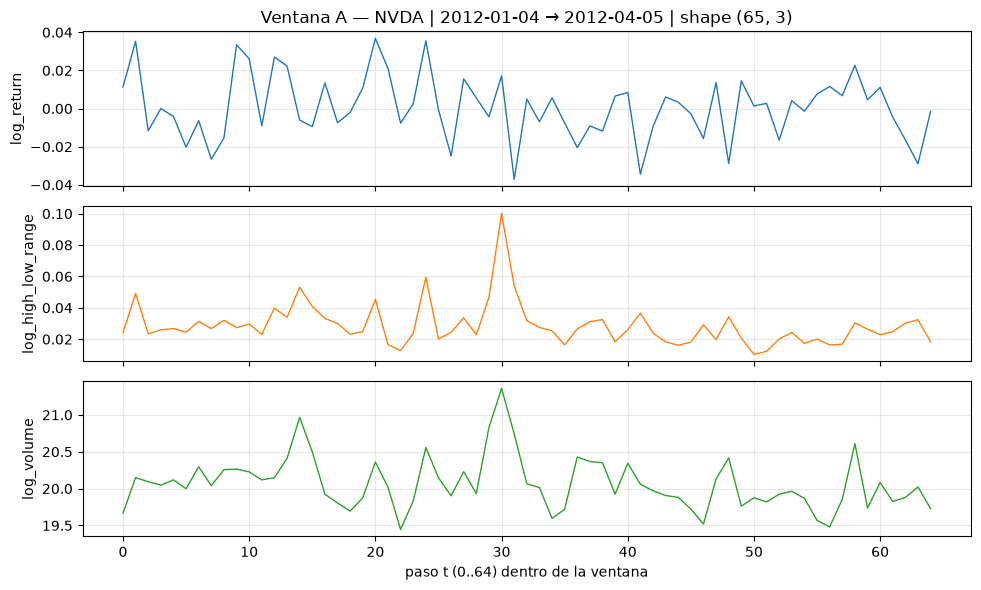

X_a shape=(65, 3); canal 0 (log_return) mean=0.0006, std=0.0168
           canal 2 (log_volume) mean=20.0675, std=0.3539


In [11]:
channel_order = manifest["window_params"]["channel_order"]
assert channel_order == ["log_return", "log_high_low_range", "log_volume"]

def pick_window(ticker: str, which: str = "first") -> pd.Series:
    block = windows.loc[windows["ticker"] == ticker].sort_values("window_end_date")
    assert len(block) > 0, f"sin ventanas para {ticker}"
    if which == "first":
        return block.iloc[0]
    if which == "middle":
        return block.iloc[len(block) // 2]
    if which == "last":
        return block.iloc[-1]
    raise ValueError(which)

def plot_window(row: pd.Series, title_prefix: str = ""):
    X = np.asarray(row["features_flat"], dtype=np.float64).reshape(65, 3)
    t = np.arange(65)
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    for i, (ax, name) in enumerate(zip(axes, channel_order)):
        ax.plot(t, X[:, i], lw=1.0, color=f"C{i}")
        ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("paso t (0..64) dentro de la ventana")
    axes[0].set_title(
        f"{title_prefix}{row['ticker']} | "
        f"{row['window_start_date'].date()} → {row['window_end_date'].date()} | shape {X.shape}"
    )
    fig.tight_layout()
    return fig, X

row_a = pick_window(TICKER, "first")
fig_a, X_a = plot_window(row_a, title_prefix="Ventana A — ")

if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    out = FIG_DIR / f"03b_window_{TICKER}.png"
    fig_a.savefig(out, dpi=120)
    print(f"guardado: {out.relative_to(ROOT)}")

plt.show()
print(f"X_a shape={X_a.shape}; canal 0 (log_return) mean={X_a[:,0].mean():.4f}, std={X_a[:,0].std():.4f}")
print(f"           canal 2 (log_volume) mean={X_a[:,2].mean():.4f}, std={X_a[:,2].std():.4f}")


### 4.2 (Opcional) Segunda ventana de otro ticker

Misma estructura, otro ticker (`TICKER_B`), para apreciar diferencias de **escala** (sobre todo en `log_volume`).


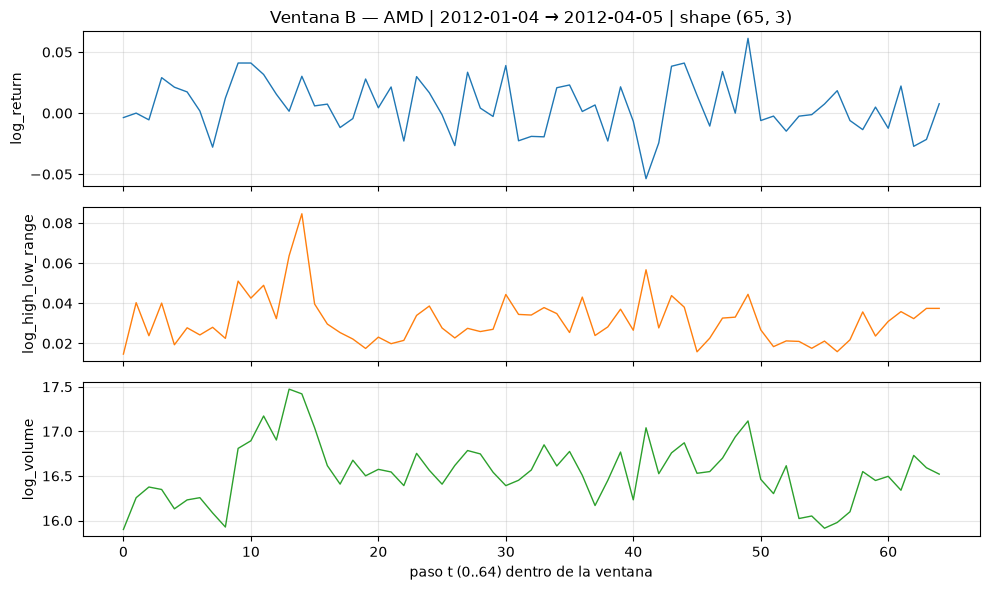

X_b shape=(65, 3); log_volume mean AMD=16.5425 vs NVDA=20.0675


In [12]:
row_b = pick_window(TICKER_B, "first")
fig_b, X_b = plot_window(row_b, title_prefix="Ventana B — ")
plt.show()
print(f"X_b shape={X_b.shape}; log_volume mean {TICKER_B}={X_b[:,2].mean():.4f} vs {TICKER}={X_a[:,2].mean():.4f}")


## 5. Check de consistencia (didáctico)

Objetivo: verificar que una ventana `features_flat` → `reshape(65, 3)` **reproduce** el slice
correspondiente de `daily_features` (mismas 65 fechas del ticker).

Esto **no** regenera features; solo comprueba alineación entre los dos artefactos ya generados.


In [13]:
# Elegimos una ventana "del medio" del TICKER para el check
row_chk = pick_window(TICKER, "middle")
X_chk = np.asarray(row_chk["features_flat"], dtype=np.float64).reshape(65, 3)

panel_t = daily.loc[daily["ticker"] == row_chk["ticker"]].sort_values("date").reset_index(drop=True)
# Alinear por rango de fechas inclusivo; deben ser exactamente 65 filas consecutivas
mask = (panel_t["date"] >= row_chk["window_start_date"]) & (panel_t["date"] <= row_chk["window_end_date"])
slice_df = panel_t.loc[mask]
Y_chk = slice_df[channel_order].to_numpy(dtype=np.float64)

print(f"ticker            : {row_chk['ticker']}")
print(f"window_start_date : {row_chk['window_start_date'].date()}")
print(f"window_end_date   : {row_chk['window_end_date'].date()}")
print(f"filas en slice    : {len(slice_df)} (esperado 65)")
print(f"X_chk shape       : {X_chk.shape}")
print(f"Y_chk shape       : {Y_chk.shape}")

assert len(slice_df) == 65, "El slice diario no tiene 65 filas — revisar huecos/fechas"
assert X_chk.shape == Y_chk.shape == (65, 3)

max_abs = float(np.max(np.abs(X_chk - Y_chk)))
tol = 1e-12
status = "PASS" if max_abs <= tol else "FAIL"
print(f"max abs diff = {max_abs:.3e}  (tol={tol:.0e}) → {status}")

# Vista rápida: primeras 3 filas lado a lado
cmp_head = pd.DataFrame(
    {
        "date": slice_df["date"].to_numpy()[:3],
        **{f"win_{c}": X_chk[:3, i] for i, c in enumerate(channel_order)},
        **{f"day_{c}": Y_chk[:3, i] for i, c in enumerate(channel_order)},
    }
)
display(cmp_head)

if status != "PASS":
    raise AssertionError(f"Check de consistencia FAIL: max_abs={max_abs}")
print("Check reshape vs daily_features: PASS")


ticker            : NVDA
window_start_date : 2018-11-13
window_end_date   : 2019-02-19
filas en slice    : 65 (esperado 65)
X_chk shape       : (65, 3)
Y_chk shape       : (65, 3)
max abs diff = 0.000e+00  (tol=1e-12) → PASS


,date,win_log_return,win_log_high_low_range,win_log_volume,day_log_return,day_log_high_low_range,day_log_volume
0,2018-11-13,0.050261,0.055216,20.284314,0.050261,0.055216,20.284314
1,2018-11-14,-0.010693,0.070330,20.081914,-0.010693,0.070330,20.081914
2,2018-11-15,0.026029,0.048912,20.549755,0.026029,0.048912,20.549755


Check reshape vs daily_features: PASS


## 6. Cierre

### Qué NO hace este notebook

- No recalcula features ni ventanas desde OHLCV.
- No escribe nada en `data/features/` (ni CSV ni parquet ni manifest).
- No hace splits train/val/test.
- No estandariza / calibra a NVDA.
- No entrena modelos (VAE / GAN / Diffusion / Ridge).
- No es un EDA estadístico profundo (eso fue el notebook 02c sobre el panel limpio).

